# NOTES
## Preprocessing steps following authors' pipeline
For (each participant):
1. Add Fz channel
2. Downsample (1000Hz -> 250Hz)
    - note: original data has 260Hz low pass filter
3. Bandpass Filter (0.1, 30Hz)
4. Remove 50Hz using notch filter
5. Remove bad channels (if more than 4: remove participant)
    - How to find bad channels: after ica, find left over artifacts and see if causing >20% epoch rejections
6. Rerefenrence (mastoid)
7. Remove bad trials (find artifacts)
8. Isolate some data to run ICA
9. Run ICA
10. Perform auto-rejection per ICLabel
11. Interpolation based on common loc

https://mne.tools/stable/auto_tutorials/preprocessing/40_artifact_correction_ica.html


**NOTES**
- nonLearners = [3 5 9 12 20 24 25 29 30 32 33]

## Results under current condition
- condition: IC rejection - eye blink > 50%

| Subject ID | Author | ours(1) | ours(2) | Notes |
|---|---|---|---|---|
| 27 | N/A | N/A | N/A | |
| 28 | N/A | N/A | N/A | |
| 29 (non learner) | N/A | N/A | | |
| 30 (non learner) | N/A | N/A | | pretty obvious channel noise at Fp1, but does not surpass the threshold \(15%\)|
| 31 | N/A | N/A | | regular troughs that look like heartbeat but not shown in ic anaylsis. need double check |
| 32 (non learner) | TP10 | N/A | | line noise present after bandpass - prove that notch filter is still necessary|
| 33 (non learner) | N/A | N/A | | muscle artifacts present but then no epochs is rejected after ica |
| 34 | N/A | N/A | | channel noise and heart beat present but no epochs is rejected after ica |
| 35 | N/A | N/A | | TP9 and TP10 are needed for interpolation. Probably bc 'other' in ICA, ugly artifacts across all channels in the plot. Need to change the current IC rejeciton criteria if we follow the same pipeline|
| 36 | N/A | N/A | | channel noise present. the regular troughs again. again only a few epochs are rejected after ica |
| 37 | N/A | N/A | | the regular troughs again. again only a few epochs are rejected after ica|
| 38 | N/A | N/A | | heart beat present but no epochs is rejected after ica |
| | | | General notes | From manual inspection there seem to be still artifacts (looks regular) after cleaning (not sure if its normal brain reaction after sitmulus or eyeblinks or heartbeats, need to take a second look.)

In [298]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [299]:
import mne
from mne_bids import (BIDSPath,read_raw_bids)
import sys
sys.path.insert(0,'.')
import os
from pathlib import Path
import numpy as np


import ccs_eeg_utils
import config
from tools import get_valid_input, get_event_dict
from binning import binning, get_group_binned_rewp
from logger import setup_rewp_logger
from visualization import show_single_psd, psd_compare, iclabel_visualize, plot_erp
from s00_add_reference import add_reference_channel, reref
from s01_downsample_filter import down_sampling, band_filter, notch_filter
from s02_drop_bad_channels import drop_bad_channels
from s03_07_trial_rejection import trial_rejection
from s04_ICA import get_ica, get_iclabel, iccomponent_removal
from s05_interpolation import interpolation
from s06_early_trial_removal import exclude_early_trials
from s07_epoching import epoching
from s08_find_bad_channels import find_bad_channels
from s09_make_erps import get_evoked, get_evoked_difference
from s10_rewp_calculation import rewp_calculation

# Set the configs

In [300]:
ACTIVE_PIPELINE = 'original'
USER = "zheng"
INSPECTION_MODE = True
SUBJECT = "38"
FIRST_RUN = False
LOG_ICA = True

In [301]:
repo_root = Path(config.__file__).resolve().parent.parent
output_dir = repo_root / "output"
plots_dir = output_dir / "plots"
ica_dir = output_dir / "ICA_objects"

# ensure common output dirs exist
output_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)
ica_dir.mkdir(parents=True, exist_ok=True)

In [302]:
# Set up the loggers for ICA
if LOG_ICA:
    logger_ica, out_ica, _ = setup_rewp_logger(
        group_label=ACTIVE_PIPELINE,
        name_prefix="ICA_results",
        out_dir=output_dir,
    )
else:
    logger_ica, out_ica = None, None

Output dir: C:\Users\Zheng\Desktop\EEG Project\EEG_Reward-Processing_ERP\output
Check log file: C:\Users\Zheng\Desktop\EEG Project\EEG_Reward-Processing_ERP\output\logs\ICA_results_original.log


In [303]:
if FIRST_RUN:
    logger_badchannel, out_badchannel, _ = setup_rewp_logger(
        group_label=ACTIVE_PIPELINE,
        name_prefix="bad_channels",
        out_dir=output_dir,
    )
else:
    logger_badchannel, out_badchannel = None, None

In [304]:
# save paths
ica_plot_savepath = plots_dir / f"{ACTIVE_PIPELINE}_sub-{SUBJECT}_excluded_ICs.pdf"
ica_savepath = ica_dir / f"{ACTIVE_PIPELINE}-sub{SUBJECT}_ica.fif"


### set up paths and read in data
cfg = config.PIPELINES[ACTIVE_PIPELINE]
root = config.BIDS_ROOT[USER]

bids_path = BIDSPath(subject=SUBJECT, task='casinos',
                     datatype='eeg', suffix='eeg',
                     root=root)

# read the file
raw = read_raw_bids(bids_path)
# fix the annotations readin
ccs_eeg_utils.read_annotations_core(bids_path,raw)

### montage setup
montage_site2_path = os.path.join(root, 'code', config.LOCS_FILENAME['site2']) 
montage_site2 = mne.channels.read_custom_montage(montage_site2_path)
montage_common_path = os.path.join(root, 'code', config.LOCS_FILENAME['common'])
montage_common = mne.channels.read_custom_montage(montage_common_path)


### Dictionary for epoching conditions
ica_trial_dict = config.CONDITIONS_DICT['onset_locked']
epoch_dict = config.CONDITIONS_DICT['feedback_locked']

### Subject info list
subject_info = config.SUBJECT_INFO

Extracting parameters from C:\Users\Zheng\Desktop\EEG Project\EEG_Reward-Processing_ERP\dataset\ds004147\ds004147\sub-38\eeg\sub-38_task-casinos_eeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\Zheng\Desktop\EEG Project\EEG_Reward-Processing_ERP\dataset\ds004147\ds004147\sub-38\eeg\sub-38_task-casinos_events.tsv.
The event "Stimulus" refers to multiple event values.Creating hierarchical event names.
    Renaming event: Stimulus -> Stimulus/S 21
    Renaming event: Stimulus -> Stimulus/S 22
    Renaming event: Stimulus -> Stimulus/S 23
    Renaming event: Stimulus -> Stimulus/S 25
    Renaming event: Stimulus -> Stimulus/S 27
    Renaming event: Stimulus -> Stimulus/S 21
    Renaming event: Stimulus -> Stimulus/S 22
    Renaming event: Stimulus -> Stimulus/S 23
    Renaming event: Stimulus -> Stimulus/S 24
    Renaming event: Stimulus -> Stimulus/S 26
    Renaming event: Stimulus -> Stimulus/S 21
    Renaming event: Stimulus -> Stimulus/S 22
    Renaming event:

C:\Users\Zheng\AppData\Local\Temp\ipykernel_20272\936589856.py:15: RuntimeWarning: Unable to map the following column(s) to to MNE:
participant: 38
date: 27-Apr-2022 14:06:19
handedness: R
order: mixed 80-20 50-50
stimuli: a cherry an orange
  raw = read_raw_bids(bids_path)


# Load the dataset

In [305]:
#raw.plot()     # visualize raw data
#raw.get_data()  # extract data as numpy
raw.load_data()  # load to memory

Reading 0 ... 2890439  =      0.000 ...  2890.439 secs...


<RawBrainVision | sub-38_task-casinos_eeg.eeg, 31 x 2890440 (2890.4 s), ~683.7 MiB, data loaded>

## Add Reference

In [306]:
raw = add_reference_channel(raw, 'Fz')

>NOTE: from manual inspection, Fp1 and Fp2 have obvious eye blinking artifacts. T7 and T8 seem to have muscle artifacts. (but leave it as it is right now)

# Set the Montage

In [307]:
raw.set_montage(montage_site2, match_case=False)

<RawBrainVision | sub-38_task-casinos_eeg.eeg, 32 x 2890440 (2890.4 s), ~705.7 MiB, data loaded>

# Downsample

In [308]:
eeg_down = down_sampling(raw.copy())

Original Sampling Rate: 1000.0 Hz
New Sampling Rate: 250.0 Hz


# Bandpass

In [309]:
eeg_band = band_filter(eeg_down.copy())

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 8251 samples (33.004 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 out of  32 | elapsed:    0.3s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  29 out of  32 | elapsed:    0.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  32 out of  32 | elapsed:    0.4s finished


# Remove 50Hz Noise

In [310]:
eeg_band_notch = notch_filter(eeg_band.copy())

[Notch] Removing: [50, 100] Hz
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 out of  32 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  29 out of  32 | elapsed:    0.3s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  32 out of  32 | elapsed:    0.3s finished


# Drop Bad Channels

In [311]:
if not FIRST_RUN:
    eeg_band_notch = drop_bad_channels(subject_info[SUBJECT]['bad_channels'][ACTIVE_PIPELINE], eeg_band_notch)   #input: bad channels from previous run, eeg

# Re-referencing

In [312]:
eeg_band_notch = reref(eeg_band_notch)

Mastoid Reference: TP9 + TP10 (average).
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


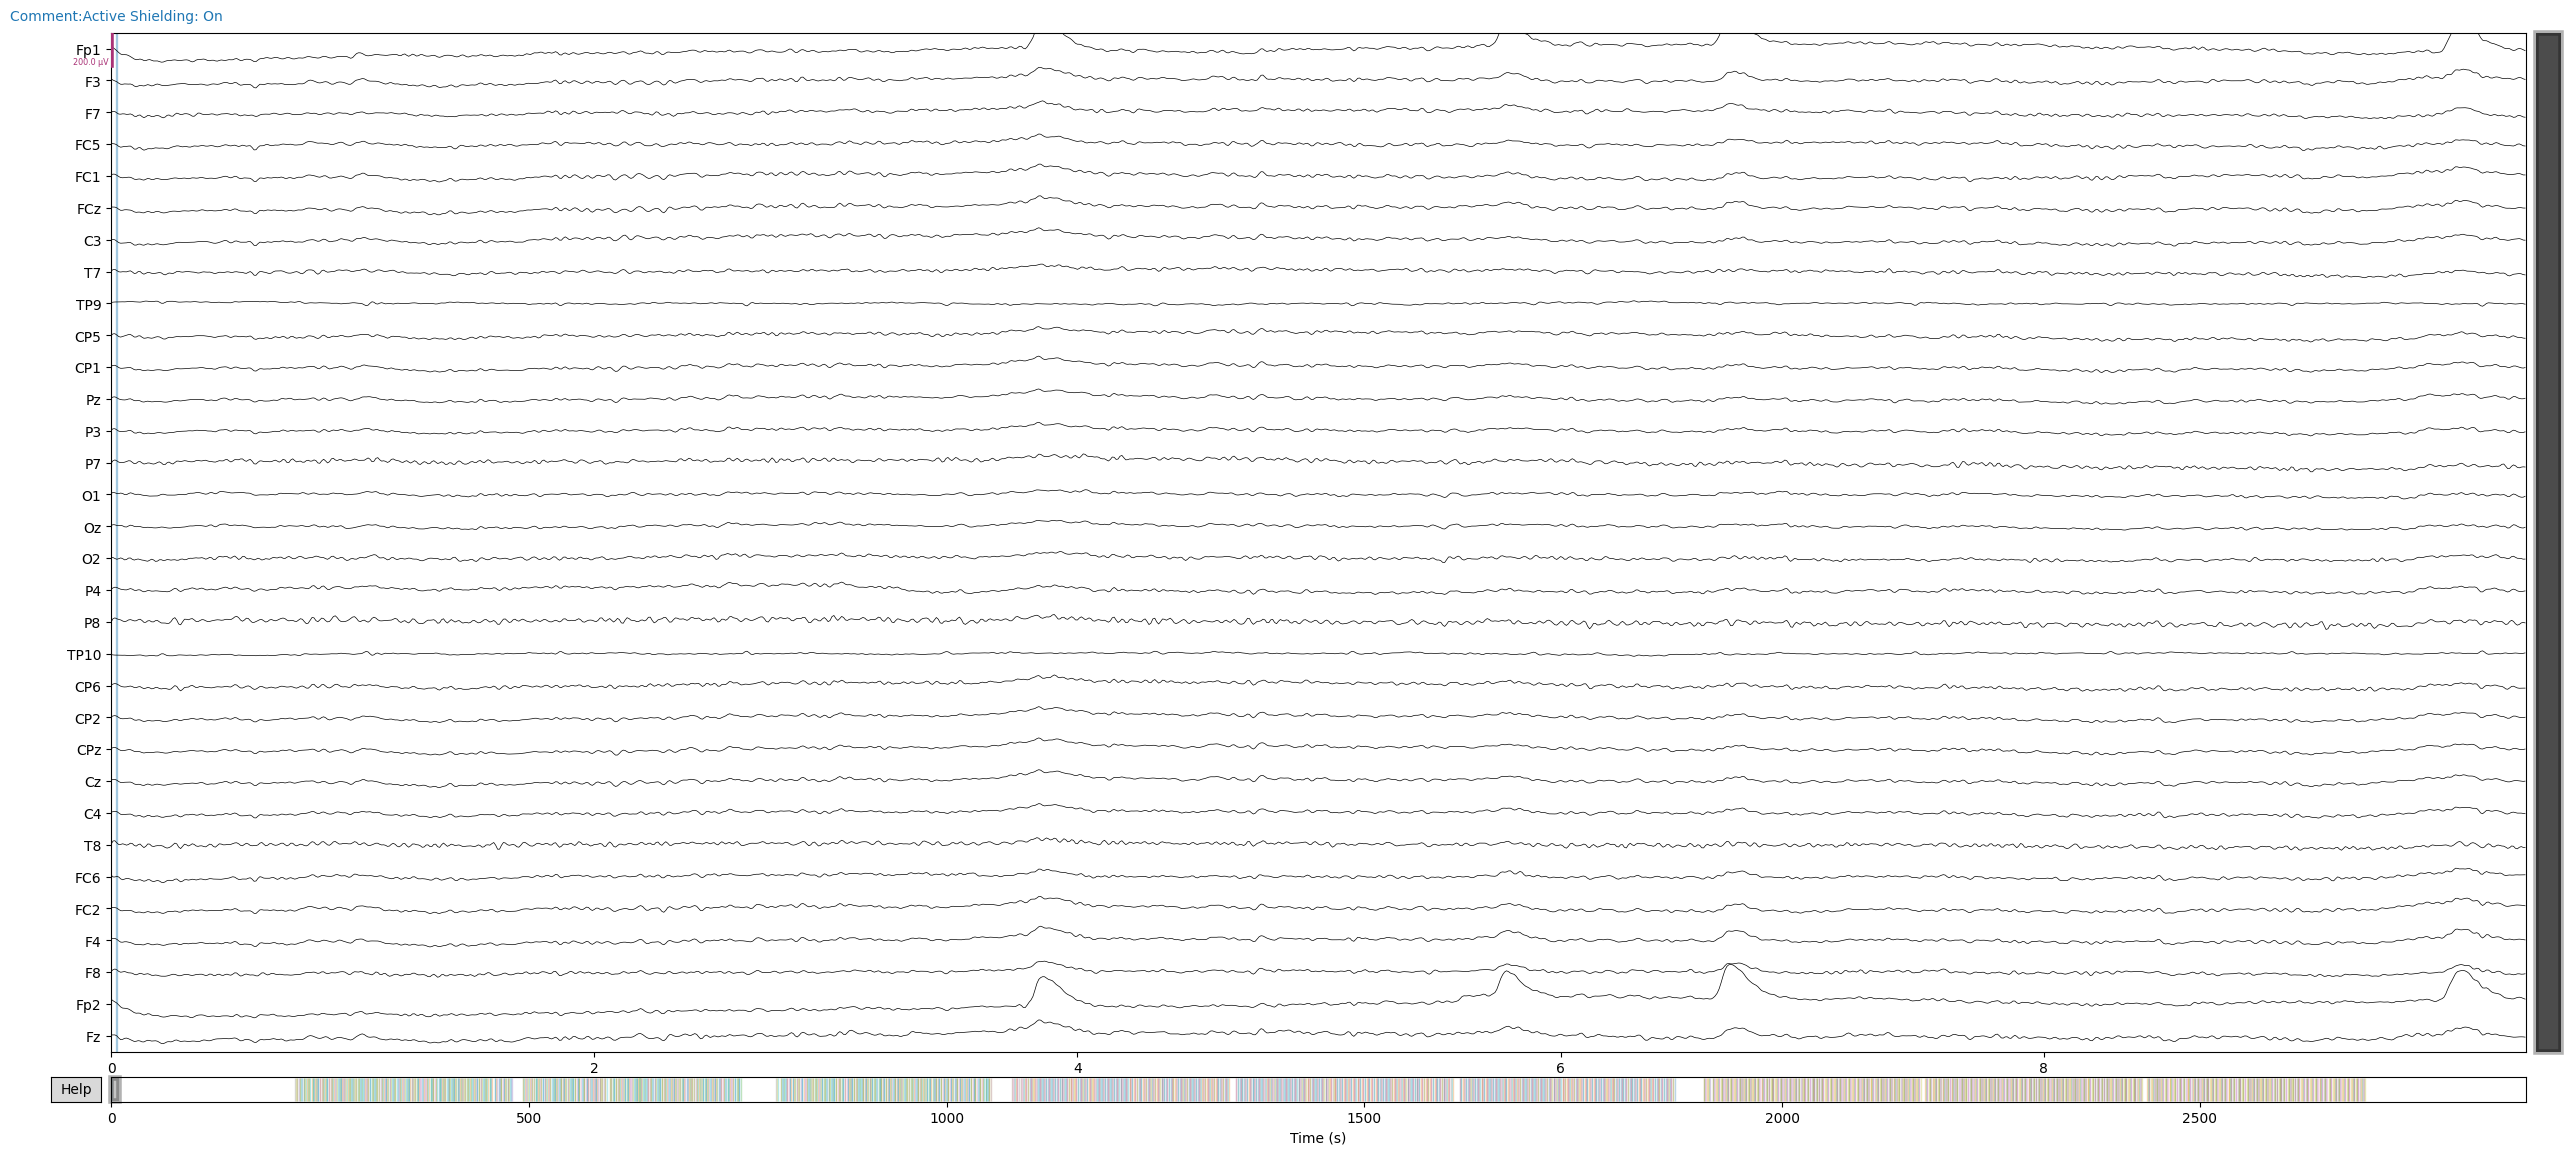

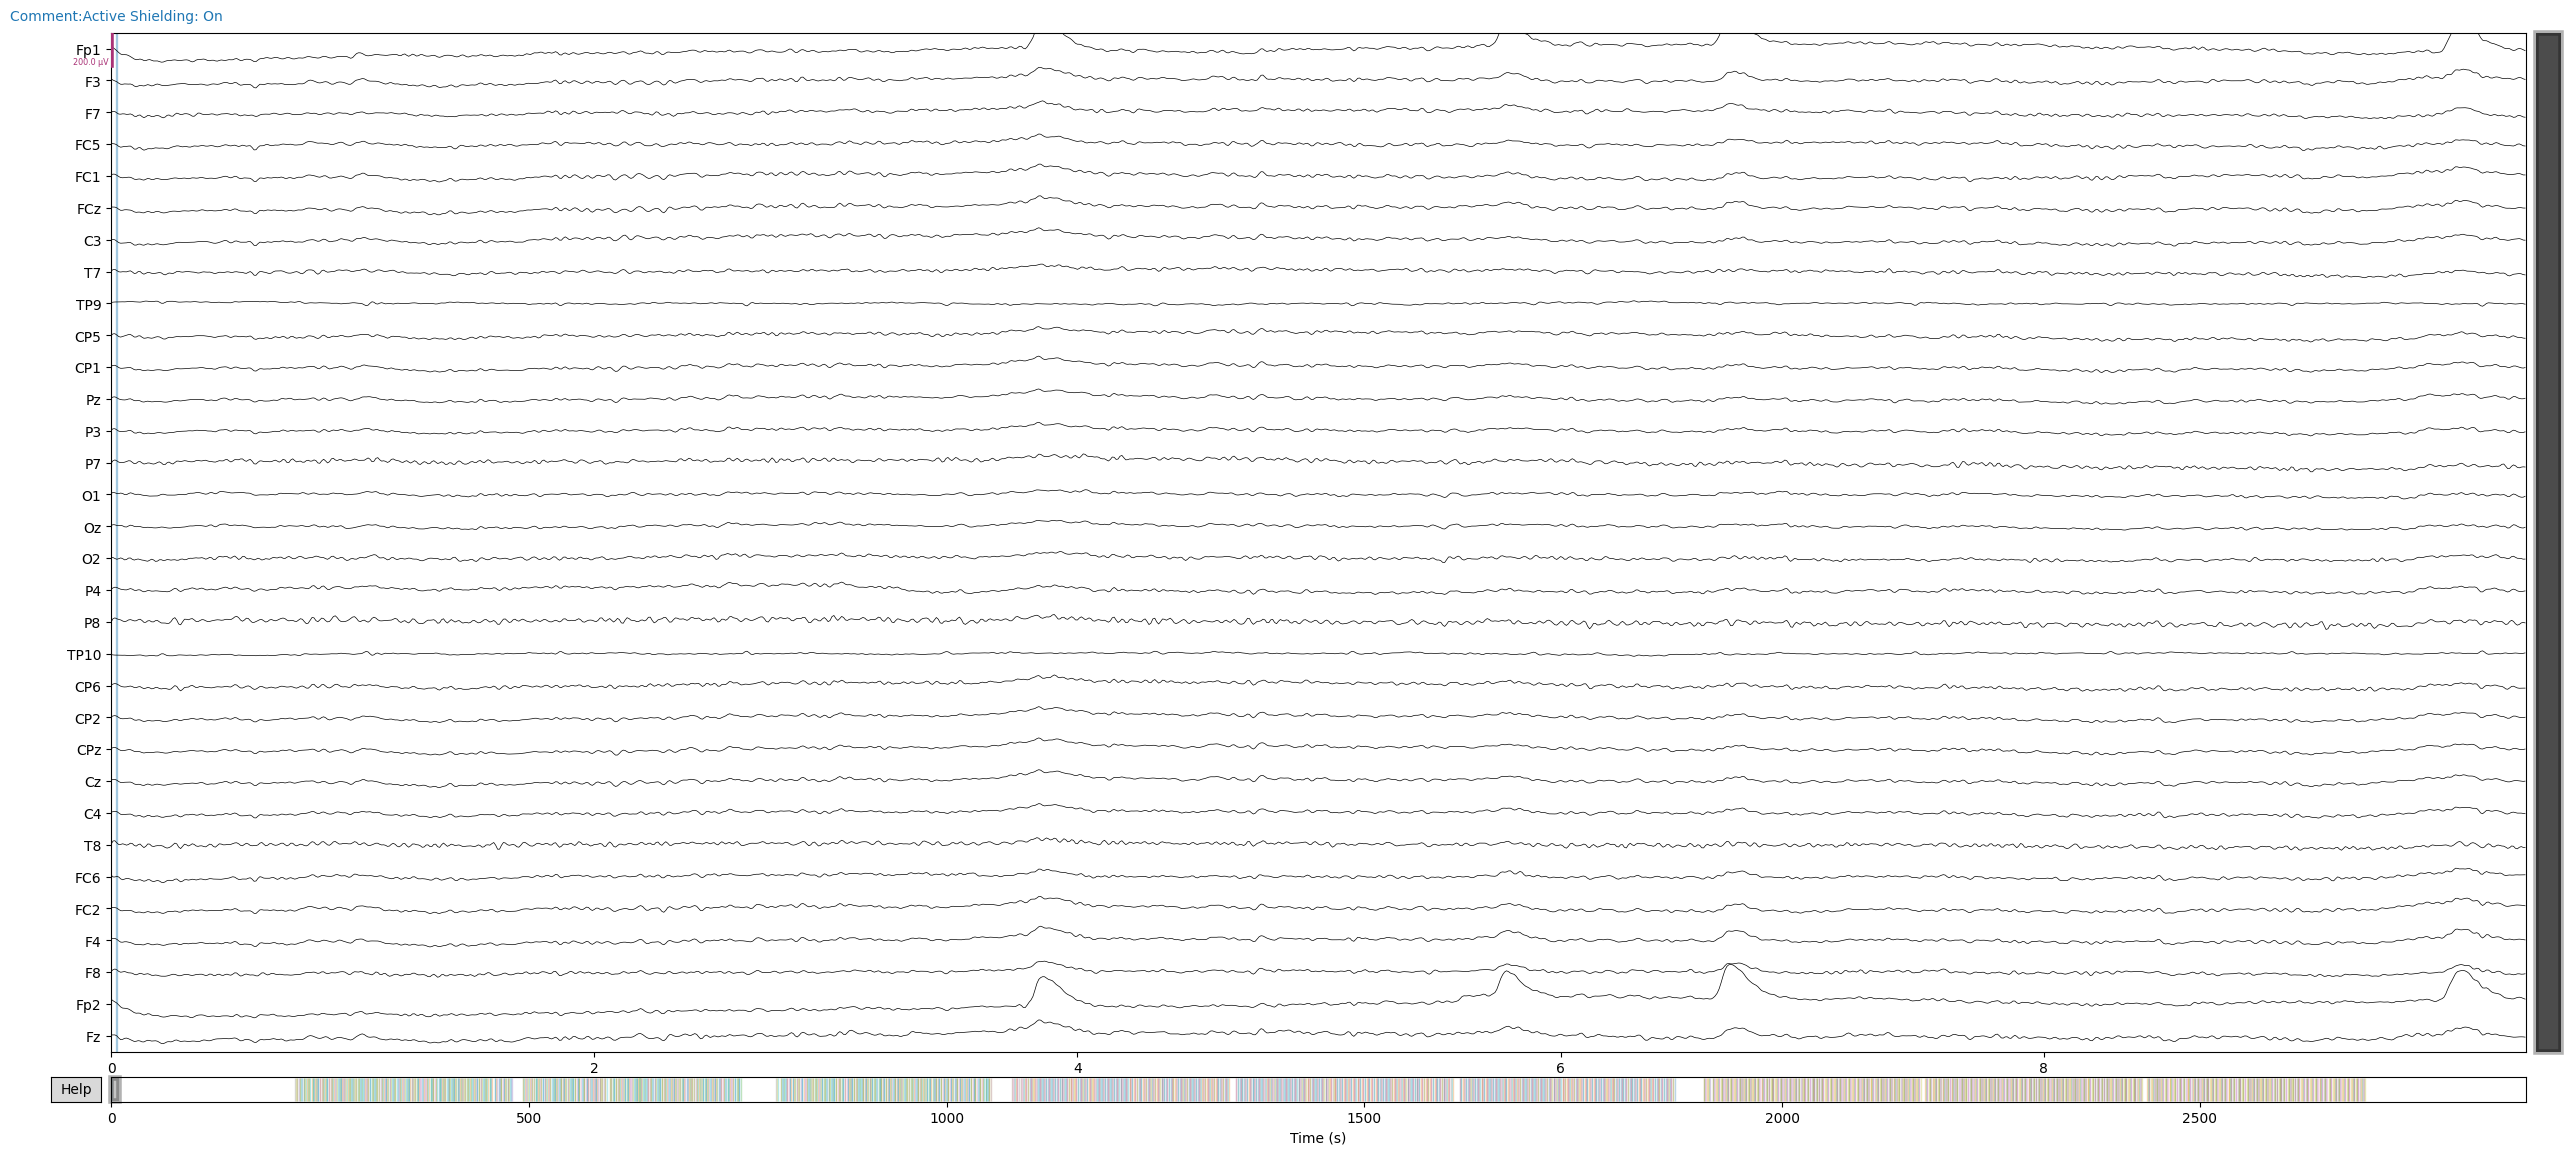

In [313]:
eeg_band_notch.plot(n_channels=32, duration=10, scalings={'eeg': 100e-6}, title="Continuous Data Check") 

# Make epochs for ICA (including bad trials removal)

In [314]:
rejection_params = config.PIPELINES[ACTIVE_PIPELINE]['rejection_params']['ica']

trials, rejection_info = trial_rejection(eeg_band_notch, ica_trial_dict, **rejection_params)
print(rejection_info)


Used Annotations descriptions: [np.str_('Comment:Active Shielding: On'), np.str_('Stimulus:S  1'), np.str_('Stimulus:S  2'), np.str_('Stimulus:S  3'), np.str_('Stimulus:S  4'), np.str_('Stimulus:S  5'), np.str_('Stimulus:S  6'), np.str_('Stimulus:S  7'), np.str_('Stimulus:S 11'), np.str_('Stimulus:S 12'), np.str_('Stimulus:S 13'), np.str_('Stimulus:S 14'), np.str_('Stimulus:S 15'), np.str_('Stimulus:S 16'), np.str_('Stimulus:S 17'), np.str_('Stimulus:S 21'), np.str_('Stimulus:S 22'), np.str_('Stimulus:S 23'), np.str_('Stimulus:S 24'), np.str_('Stimulus:S 25'), np.str_('Stimulus:S 26'), np.str_('Stimulus:S 27'), np.str_('Stimulus:S 31'), np.str_('Stimulus:S 32'), np.str_('Stimulus:S 33'), np.str_('Stimulus:S 34'), np.str_('Stimulus:S 35'), np.str_('Stimulus:S 36'), np.str_('Stimulus:S 37')]
Dropped 1 epoch: 178
{np.int64(178): ['Fp1', 'F3', 'F7', 'O1', 'Oz', 'O2', 'Fp2', 'Fz']}


# ICA analysis

Difference between 3 ICA methods:
- Runica (infomax)
- Picard
- Fastica

>NOTE: need to add random seed, for ICA calculation introduce randomness and the results may be different every time

>NOTE: the authors used 'runica' -> 'infomax'

IClabel_componnet:
https://github.com/mne-tools/mne-icalabel/blob/main/mne_icalabel/label_components.py


https://mne.tools/mne-icalabel/dev/generated/api/mne_icalabel.iclabel.iclabel_label_components.html


In [315]:

if FIRST_RUN:
    ica = get_ica(trials, config.PIPELINES[ACTIVE_PIPELINE]['ica_method'], save_path=None)
else:
    # try to load existing ICA first
    try:
        ica = mne.preprocessing.read_ica(ica_savepath)
    except FileNotFoundError:
        # fit and save so subsequent runs can load it
        save = ica_savepath if LOG_ICA else None
        ica = get_ica(trials, config.PIPELINES[ACTIVE_PIPELINE]['ica_method'], save_path=save)

eeg_band_notch = iccomponent_removal(eeg_band_notch, trials, ica, SUBJECT, ACTIVE_PIPELINE, logger_ica, ica_plot_savepath)

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Using data from preloaded Raw for 431 events and 751 original time points ...
Selecting by non-zero PCA components: 31 components
Computing Extended Infomax ICA
Using data from preloaded Raw for 431 events and 751 original time points ...
Fitting ICA took 42.9s.
Writing ICA solution to C:\Users\Zheng\Desktop\EEG Project\EEG_Reward-Processing_ERP\output\ICA_objects\original-sub38_ica.fif...


Subject 38: Excluded 5/31 ICs -> [0, 1, 5, 10, 14]


ICA object saved to C:\Users\Zheng\Desktop\EEG Project\EEG_Reward-Processing_ERP\output\ICA_objects\original-sub38_ica.fif
Applying ICA to Raw instance
    Transforming to ICA space (31 components)
    Zeroing out 5 ICA components
    Projecting back using 32 PCA components


## Interpolation

In [316]:
eeg_band_notch = interpolation(eeg_band_notch, montage_common)

Removing extra channels: ['TP9', 'O1', 'O2', 'TP10', 'CPz']
Adding placeholders for missing channels: ['PO7', 'POz', 'PO8']
Interpolating channels: ['PO7', 'PO8', 'POz']
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 27 sensor positions
Interpolating 3 sensors


c:\Users\Zheng\Desktop\EEG Project\EEG_Reward-Processing_ERP\scripts\s05_interpolation.py:31: RuntimeWarning: Location for this channel is unknown or ambiguous; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
  data.add_reference_channels(missing_channels)


## Remove the first few trials from each task

In [317]:
eeg_final = exclude_early_trials(eeg_band_notch, config.PIPELINES[ACTIVE_PIPELINE]['early_trial_deletion'])

Used Annotations descriptions: [np.str_('Comment:Active Shielding: On'), np.str_('Stimulus:S  1'), np.str_('Stimulus:S  2'), np.str_('Stimulus:S  3'), np.str_('Stimulus:S  4'), np.str_('Stimulus:S  5'), np.str_('Stimulus:S  6'), np.str_('Stimulus:S  7'), np.str_('Stimulus:S 11'), np.str_('Stimulus:S 12'), np.str_('Stimulus:S 13'), np.str_('Stimulus:S 14'), np.str_('Stimulus:S 15'), np.str_('Stimulus:S 16'), np.str_('Stimulus:S 17'), np.str_('Stimulus:S 21'), np.str_('Stimulus:S 22'), np.str_('Stimulus:S 23'), np.str_('Stimulus:S 24'), np.str_('Stimulus:S 25'), np.str_('Stimulus:S 26'), np.str_('Stimulus:S 27'), np.str_('Stimulus:S 31'), np.str_('Stimulus:S 32'), np.str_('Stimulus:S 33'), np.str_('Stimulus:S 34'), np.str_('Stimulus:S 35'), np.str_('Stimulus:S 36'), np.str_('Stimulus:S 37')]
Excluded 146 events (first 10 trials of each block).


# Epoching & find leftover artifacts

In [318]:
rejection_params = config.PIPELINES[ACTIVE_PIPELINE]['rejection_params']['erp']
bad_channel_criteria = config.PIPELINES[ACTIVE_PIPELINE]['bad_channels_rejection_criteria']

epochs_all, rejection_info = epoching(eeg_final, epoch_dict,  **rejection_params)
find_bad_channels(epochs_all, reject_criteria=bad_channel_criteria, rejection_info=rejection_info, subject_id=SUBJECT, logger=logger_badchannel)


Used Annotations descriptions: [np.str_('Comment:Active Shielding: On'), np.str_('Stimulus:S  1'), np.str_('Stimulus:S  2'), np.str_('Stimulus:S  3'), np.str_('Stimulus:S  4'), np.str_('Stimulus:S  5'), np.str_('Stimulus:S  6'), np.str_('Stimulus:S  7'), np.str_('Stimulus:S 11'), np.str_('Stimulus:S 12'), np.str_('Stimulus:S 13'), np.str_('Stimulus:S 14'), np.str_('Stimulus:S 15'), np.str_('Stimulus:S 16'), np.str_('Stimulus:S 17'), np.str_('Stimulus:S 21'), np.str_('Stimulus:S 22'), np.str_('Stimulus:S 23'), np.str_('Stimulus:S 24'), np.str_('Stimulus:S 25'), np.str_('Stimulus:S 26'), np.str_('Stimulus:S 27'), np.str_('Stimulus:S 31'), np.str_('Stimulus:S 32'), np.str_('Stimulus:S 33'), np.str_('Stimulus:S 34'), np.str_('Stimulus:S 35'), np.str_('Stimulus:S 36'), np.str_('Stimulus:S 37')]
Dropped 0 epochs: 
--- Channel Rejection Summary (Total Epochs: 397) ---
---------------------------------
Channels exceeding 20% threshold: []


[]

# Make ERP

use trimmed mean
compare with the original method?

In [319]:
all_evokeds = get_evoked(epoch_dict, epochs_all, proportiontocut=config.PIPELINES[ACTIVE_PIPELINE]['evoked_proportiontocut'])

Using data from preloaded Raw for 72 events and 201 original time points ...
Using data from preloaded Raw for 62 events and 201 original time points ...
Using data from preloaded Raw for 25 events and 201 original time points ...
Using data from preloaded Raw for 41 events and 201 original time points ...
Using data from preloaded Raw for 46 events and 201 original time points ...
Using data from preloaded Raw for 17 events and 201 original time points ...
Using data from preloaded Raw for 78 events and 201 original time points ...
Using data from preloaded Raw for 56 events and 201 original time points ...


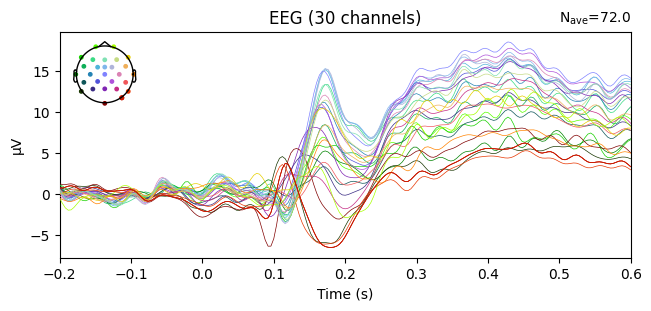

In [320]:
if INSPECTION_MODE == True:
    # butterfly graph for one condition
    evoked_Low_Low_Win = all_evokeds['Low-Low Win']
    evoked_Low_Low_Win.plot();

In [321]:
print(all_evokeds)

{'Low-Low Win': <Evoked | 'Low-Low Win' (average, N=72.0), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'Low-Low Loss': <Evoked | 'Low-Low Loss' (average, N=62.0), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'Mid-Low Win': <Evoked | 'Mid-Low Win' (average, N=25.0), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'Mid-Low Loss': <Evoked | 'Mid-Low Loss' (average, N=41.0), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'Mid-High Win': <Evoked | 'Mid-High Win' (average, N=46.0), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'Mid-High Loss': <Evoked | 'Mid-High Loss' (average, N=17.0), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'High-High Win': <Evoked | 'High-High Win' (average, N=78.0), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'High-High Loss': <Evoked | 'High-High Loss' (average, N=56.0), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>}


# RewP Calculation

In [322]:
rewp_calculation(all_evokeds, epoch_dict)

[Low-Low] Mean:  7.49 µV | P2P:  6.79 µV
[Mid-Low] Mean:  8.49 µV | P2P:  8.35 µV
[Mid-High] Mean:  8.52 µV | P2P: 11.43 µV
[High-High] Mean:  8.59 µV | P2P:  6.26 µV


{'Low-Low': {'mean': np.float64(7.48558220528591),
  'p2p': np.float64(6.793713838012747)},
 'Mid-Low': {'mean': np.float64(8.493112184783808),
  'p2p': np.float64(8.349350509590158)},
 'Mid-High': {'mean': np.float64(8.51558811331835),
  'p2p': np.float64(11.428719026721744)},
 'High-High': {'mean': np.float64(8.586820490281903),
  'p2p': np.float64(6.2618868069757045)}}

# RewP Plotting

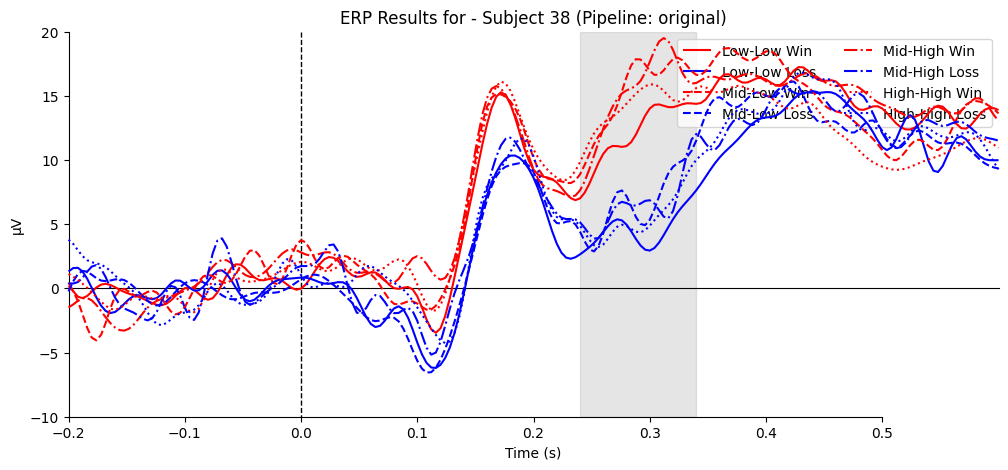

In [323]:
#NOTE: need to set y-axis to a fixed range for better comparison across subjects
plot_erp(all_evokeds, ylim=[-10, 20], diff=False, title=f"ERP Results for - Subject {SUBJECT} (Pipeline: {ACTIVE_PIPELINE})");

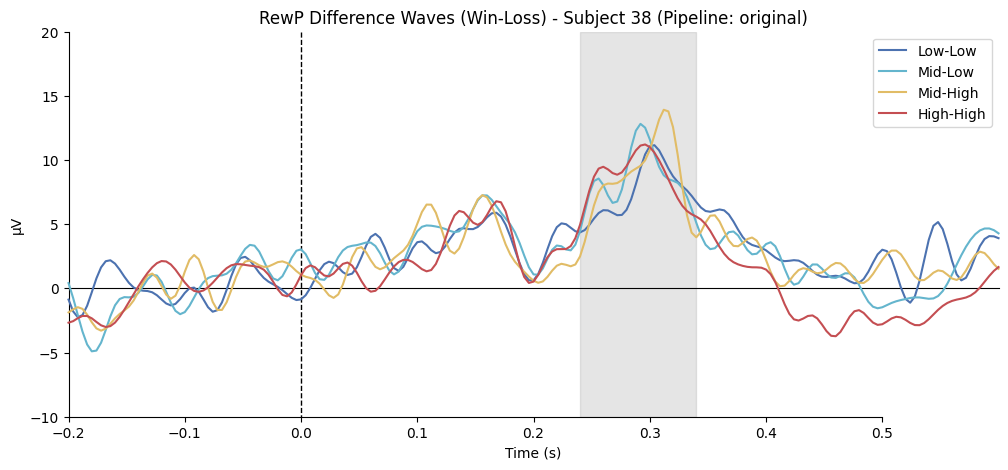

In [324]:
diff_evokeds = get_evoked_difference(all_evokeds)
plot_erp(diff_evokeds, diff=True, title=f"RewP Difference Waves (Win-Loss) - Subject {SUBJECT} (Pipeline: {ACTIVE_PIPELINE})")